# Boléro as a spiral

Score-driven, not audio-driven — sibling to `ode_to_joy_landscape.ipynb` / `fate_motif_storm.ipynb` / `william_tell_gallop.ipynb` / `overture_1812_finale.ipynb`. No recording, no synthesis, no copyright question.

Structure and melodic character verified against real sources before building, not recalled from memory:

- **Repeat structure** (Tucson Symphony program notes, "Boléro: Ravel's Lesson in Orchestral Crescendo and Repetition" [classicalcomposer.org], IMSLP full score, Durand 1929): the two-strain theme (A, B) is stated as one block **A A B B** (4 statements per cycle), repeating **4 times complete**, then a **5th, partial block** (2 statements) right before the close — **18 individually-orchestrated statements total**, each strain heard 9 times. A fixed 2-bar/8-beat snare ostinato never varies. Orchestration only adds. A sudden E major shift hits for 8 bars right before the end (rehearsal 18), snapping back to C major for the tutti crash.
- **Melodic character and real spiral analysis** (Bhogal, "Turning Inward in Maurice Ravel's *Boléro*," *Music Theory Online* 26.2, 2020): Ravel's two themes have distinct, named shapes in the actual musicological literature — the **decorative** melody (theme A) is narrow, ornamented, "incessant noodling around the same pitches within a narrow tessitura." The **arabesque** melody (theme B) is "a long, unbroken legato phrase" with a "languorous contour" that undergoes "a gradual descent through the octave to a low point." Bhogal's own analysis already reads *Boléro*'s form as a spiral: decorative statements are **outward turning**, arabesque statements are **inward turning**, and "the widening of each spiral rotation captures the growing dynamics." One quoted detail placed the E major disruption specifically in "the continuation of the arabesque melody" — used below to assign B, not A, to the rupture statement.

Mapping: each of the 18 statements traces its **own full closed 360° loop** — the melody completes the circle, as it should if the shape is meant to be recognized rather than just themed. Successive loops step outward (wider) and brighter (louder), same principle Bhogal describes. Within each loop, decorative (A) statements bulge **outward** with small ornamented ripples; arabesque (B) statements dip **inward** as one long smooth sweep — both real, sourced, opposite behaviors, not invented for symmetry. The ostinato is small star markers riding directly on each melody's own contour at fixed angular spacing — the pulse that never changes, always present under whichever shape is currently playing. The E major statement (an arabesque/B loop per Bhogal) breaks from the established warm color into cold teal with an added outward spike — the "malfunction" — before the final loop snaps back to the warm palette at max brightness for the tutti crash.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ---- Verified structure (see markdown cell above for sources) ----
STATEMENT_INSTRUMENTS = [
    "flute", "clarinet", "bassoon", "E-flat clarinet",
    "oboe d'amore", "muted trumpet + flute", "tenor saxophone",
    "soprano/sopranino saxophone", "horn + celesta",
    "oboe + cor anglais + clarinets", "trombone", "high woodwinds",
    "1st violins + winds", "violins (fuller)", "violins + winds (fuller still)",
    "most of the orchestra", "full orchestra — E major deviation",
    "full orchestra — tutti crash (C major)",
]
N = len(STATEMENT_INSTRUMENTS)
GROUP_SIZES = [4, 4, 4, 4, 2]  # 4 full A-A-B-B cycles + 1 closing partial cycle

# melody label per statement: each full group of 4 is the real A-A-B-B pattern.
# The final partial group is B-then-A (not A-then-B) because Bhogal specifically
# places the E major "malfunction" in the arabesque (B) melody's continuation --
# see markdown cell.
MELODY = []
for g in GROUP_SIZES[:-1]:
    half = g // 2
    MELODY += ["A"] * half + ["B"] * half
MELODY += ["B", "A"]

E_MAJOR_IDX = N - 2  # statement 17 (0-indexed 16): the deviation
CRASH_IDX = N - 1    # statement 18: the tutti crash

# self-check: the whole spiral's loop count and melody balance follow directly
# from this structure
assert N == 18
assert sum(GROUP_SIZES) == N
assert len(MELODY) == N
assert MELODY.count("A") == 9 and MELODY.count("B") == 9
print(f"{N} statements ({MELODY.count('A')}x decorative/A, {MELODY.count('B')}x arabesque/B), "
      f"each its own full spiral loop")

18 statements (9x decorative/A, 9x arabesque/B), each its own full spiral loop


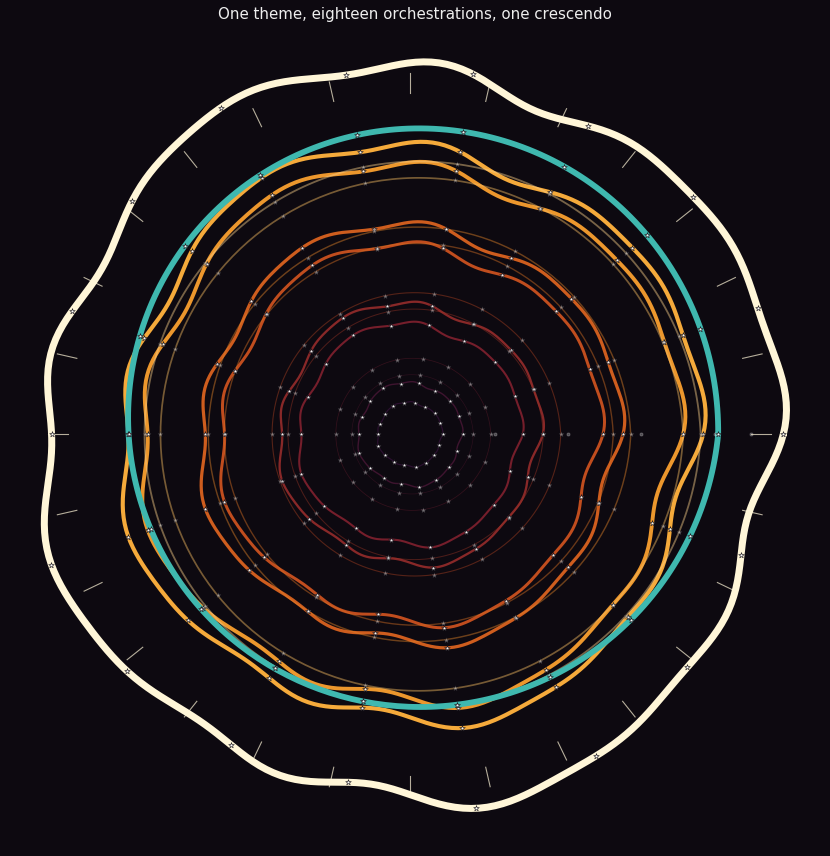

In [10]:
r0, dr = 0.9, 0.55           # each statement's loop steps this far outward from the last
AMP_FRAC = 0.13               # wiggle amplitude as a fraction of the loop's own base radius
RUPTURE_BUMP = 0.5            # extra outward spike on the E major "malfunction"
PHASE_STEP = 0.0              # no rotation -- ripples/dips stay aligned ring to ring
B_LW_SCALE = 0.4               # arabesque/B loops drawn thinner than the decorative/A loops...
B_ALPHA = 0.45                 # ...and dimmer, so A's repeated shape stays the readable one

def ring_base(i):
    return r0 + i * dr

def contour_A(theta, amp):
    # decorative: narrow, ornamented, several small ripples, net OUTWARD bulge
    # (Bhogal 2020: "outward turning decorative melody")
    ripple = (0.5 * np.sin(4 * theta) + 0.3 * np.sin(9 * theta + 0.7)
              + 0.2 * np.sin(13 * theta + 1.3))
    return amp * (0.55 + 0.45 * ripple)

def contour_B(theta, amp):
    # arabesque: one long legato sweep, net INWARD dip
    # (Bhogal 2020: "inward turning arabesque melody"; also "gradual descent... to a low point")
    sweep = np.sin(np.pi * (theta / (2 * np.pi)))  # 0 at both ends, peak at the middle
    return -amp * (0.35 + 0.65 * sweep)

cmap = LinearSegmentedColormap.from_list(
    "bolero_crescendo", ["#2b1030", "#7a1f2b", "#c9531c", "#f4a531", "#fff6d8"]
)
RUPTURE_COLOR = "#3fb8af"  # cold teal, deliberately outside the warm crescendo ramp

fig, ax = plt.subplots(figsize=(13, 12), facecolor="#0d0910")
ax.set_facecolor("#0d0910")

theta = np.linspace(0, 2 * np.pi, 300)
cycle_end_idx = set(np.cumsum(GROUP_SIZES))  # statement indices (1-based) closing a cycle

for i, (instrument, melody) in enumerate(zip(STATEMENT_INSTRUMENTS, MELODY)):
    build_frac = i / (N - 1)
    base = ring_base(i)
    amp = AMP_FRAC * base
    phase = i * PHASE_STEP  # rotate each loop so ripples/dips don't stack radially across rings

    wiggle = contour_A(theta + phase, amp) if melody == "A" else contour_B(theta + phase, amp)
    r = base + wiggle
    draw_theta = theta  # actual plotted angle stays 0..2pi; only the contour's *phase* shifts

    alpha = 1.0
    if i == E_MAJOR_IDX:
        r = r + RUPTURE_BUMP * np.sin(theta)  # the "malfunction" -- one added outward spike
        color, lw = RUPTURE_COLOR, 2.8 + 3.2 * build_frac
    elif i == CRASH_IDX:
        color, lw = "#fff6d8", 7.0
    elif melody == "B":
        color, lw = cmap(build_frac), (1.2 + 3.8 * build_frac) * B_LW_SCALE
        alpha = B_ALPHA
    else:
        color, lw = cmap(build_frac), 1.2 + 3.8 * build_frac

    x, y = r * np.cos(draw_theta), r * np.sin(draw_theta)
    ax.plot(x, y, color=color, linewidth=lw, alpha=alpha, solid_capstyle="round", zorder=3)

    # ostinato: small stars riding directly on this loop's own contour, fixed angular
    # spacing regardless of melody shape -- the pulse that never changes. Sized/outlined
    # for a hard, percussive "hit" rather than a soft sparkle -- staccato, not glow.
    tick_theta = np.arange(0, 2 * np.pi, np.pi / 9)
    tw = contour_A(tick_theta + phase, amp) if melody == "A" else contour_B(tick_theta + phase, amp)
    tr = base + tw
    if i == E_MAJOR_IDX:
        tr = tr + RUPTURE_BUMP * np.sin(tick_theta)
    star_alpha = 0.95 if melody == "A" or i in (E_MAJOR_IDX, CRASH_IDX) else 0.95 * B_ALPHA
    ax.scatter(tr * np.cos(tick_theta), tr * np.sin(tick_theta), s=34, marker="*", 
               color="#ffffff", alpha=star_alpha, linewidths=0.6, edgecolors="#0d0910",
               zorder=6)

    if (i + 1) in cycle_end_idx:
        ax.plot(base * np.cos(0), base * np.sin(0), marker="o", markersize=3,
                 color="#ffffff40", zorder=5)

# tutti crash burst
r_end = ring_base(CRASH_IDX)
for ang in np.linspace(0, 2 * np.pi, 28, endpoint=False):
    ax.plot([r_end * np.cos(ang), (r_end + 0.6) * np.cos(ang)],
            [r_end * np.sin(ang), (r_end + 0.6) * np.sin(ang)],
            color="#fff6d8", linewidth=1.1, alpha=0.7, zorder=5)

R = ring_base(CRASH_IDX) + AMP_FRAC * ring_base(CRASH_IDX) + RUPTURE_BUMP + 1.0
# ax.set_xlim(-R * 1.55, R * 1.05)  # dedicated left margin for the legend, clear of the rings
# ax.set_ylim(-R * 1.05, R * 1.05)
ax.set_aspect("equal")
ax.axis("off")

# legend_lines = [f"{i+1:>2}. [{m}] {instrument}" for i, (instrument, m) in
#                 enumerate(zip(STATEMENT_INSTRUMENTS, MELODY))]
# ax.text(-R * 1.5, R * 0.98, "\n".join(legend_lines), color="#ddddddaa",
#         fontsize=8, family="monospace", va="top", ha="left", linespacing=1.55)

ax.set_title("One theme, eighteen orchestrations, one crescendo",
             color="#eeeeee", fontsize=15, )

fig.tight_layout()
fig.savefig("bolero_spiral.png", dpi=200, facecolor=fig.get_facecolor())
plt.show()